In [1]:
import brainpy as bp
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import jax.numpy as jnp
import sys
import os

src_dir = os.path.abspath(os.path.join('../..', 'src'))
sys.path.insert(0, src_dir)

from model import WRCircuit
from plots import animate_spiking_activity
from heterogeneousei import EmbeddedLif, HeterogenousCircuit

/home/brendan/OneDrive/Masters/Code/Vortices/Julia/WRCircuit/.CondaPkg/env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from scipy.sparse import csr_matrix
HeterogeneousNet = HeterogenousCircuit(10000, 2500)
HeterogeneousNet.I
if np.product(HeterogeneousNet.E.size) <= 50:
    conn = HeterogeneousNet.E2E.conn
    positions = HeterogeneousNet.E.positions
    if len(positions[0]) == 1:
        positions = [(np.sin(x[0]), np.cos(x[0])) for x in positions]
    G = nx.from_numpy_array(conn.require("conn_mat"), create_using=nx.DiGraph())
    plt.figure(figsize=(10,10))
    list_degree=list(G.in_degree()) #this will return a list of tuples each tuple is(node,deg)
    nodes , degree = map(list, zip(*list_degree)) #build a node list and corresponding degree list

    nx.draw(
        G,
        pos=positions,
        connectionstyle="arc3,rad=0.5",
        node_color="b",
        edge_color="b",
        nodelist=nodes,
        node_size=[(v * 20)+1 for v in degree],
        width=0.5,
    )


    conn = HeterogeneousNet.I2I.conn
    positions = HeterogeneousNet.I.positions
    if len(positions[0]) == 1:
        positions = [(np.sin(x[0]), np.cos(x[0])) for x in positions]
    G = nx.from_numpy_array(conn.require("conn_mat"), create_using=nx.DiGraph())
    nx.draw(G, pos=positions, node_color="r", node_size=20, edge_color="r")

    conn = HeterogeneousNet.E2I.conn
    conn_mat = csr_matrix(conn.require("conn_mat"))
    B = nx.bipartite.from_biadjacency_matrix(conn_mat)
    pos = {}
    pos.update((i, (np.sin(x[0]), np.cos(x[0]))) for i, x in enumerate(HeterogeneousNet.E.positions))
    pos.update((i+len(HeterogeneousNet.E.positions), (np.sin(x[0]), np.cos(x[0]))) for i, x in enumerate(HeterogeneousNet.I.positions))
    nx.draw_networkx_edges(B, pos=pos, node_size=20, edge_color="g")

    conn = HeterogeneousNet.I2E.conn
    conn_mat = csr_matrix(conn.require("conn_mat"))
    B = nx.bipartite.from_biadjacency_matrix(conn_mat)
    pos = {}
    pos.update((i, (np.sin(x[0]), np.cos(x[0]))) for i, x in enumerate(HeterogeneousNet.I.positions))
    pos.update((i+len(HeterogeneousNet.I.positions), (np.sin(x[0]), np.cos(x[0]))) for i, x in enumerate(HeterogeneousNet.E.positions))
    nx.draw_networkx_edges(B, pos=pos, node_size=20, edge_color="y")

    plt.show()

/home/brendan/OneDrive/Masters/Code/Vortices/Julia/WRCircuit/.CondaPkg/env/lib/python3.11/site-packages/jax/_src/ops/scatter.py:96: FutureWarning: scatter inputs have incompatible types: cannot safely cast value from dtype=int32 to dtype=uint32 with jax_numpy_dtype_promotion='standard'. In future JAX releases this will result in an error.
  warnings.warn(
/home/brendan/OneDrive/Masters/Code/Vortices/Julia/WRCircuit/.CondaPkg/env/lib/python3.11/site-packages/jax/_src/ops/scatter.py:96: FutureWarning: scatter inputs have incompatible types: cannot safely cast value from dtype=int32 to dtype=uint32 with jax_numpy_dtype_promotion='standard'. In future JAX releases this will result in an error.
  warnings.warn(
/home/brendan/OneDrive/Masters/Code/Vortices/Julia/WRCircuit/.CondaPkg/env/lib/python3.11/site-packages/jax/_src/ops/scatter.py:96: FutureWarning: scatter inputs have incompatible types: cannot safely cast value from dtype=int32 to dtype=uint32 with jax_numpy_dtype_promotion='standar

In [3]:
T = 1000.0
# HeterogenousNet.stimulus = bp.dyn.PoissonInput(HeterogenousNet.Ein.input, np.prod(HeterogenousNet.E.size), 100.0, 1.0)
runner = bp.DSRunner(
    HeterogeneousNet,
    monitors=["E.spike", "I.spike", "E.V", "I.V"],
    jit = True
)
runner.run(T)
t = runner.mon["ts"].view()  # [1000:]
X = runner.mon["E.spike"].view()  # [1000:]
Ve = runner.mon["E.V"].view()  # [1000:]
Vi = runner.mon["I.V"].view()  # [1000:]

Predict 10000 steps: : 100%|██████████| 10000/10000 [00:04<00:00, 2221.68it/s]


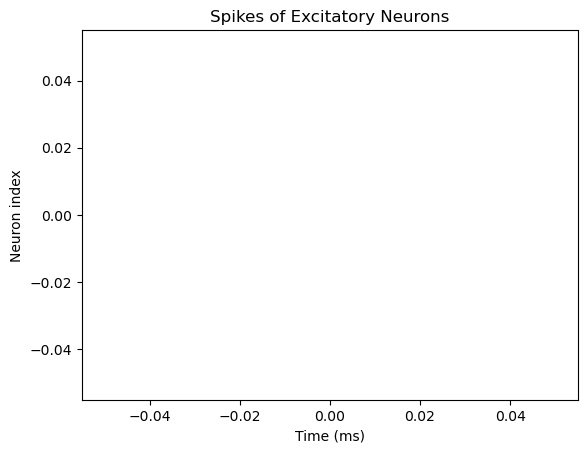

In [4]:
bp.visualize.raster_plot(t, X, title="Spikes of Excitatory Neurons", show=True)

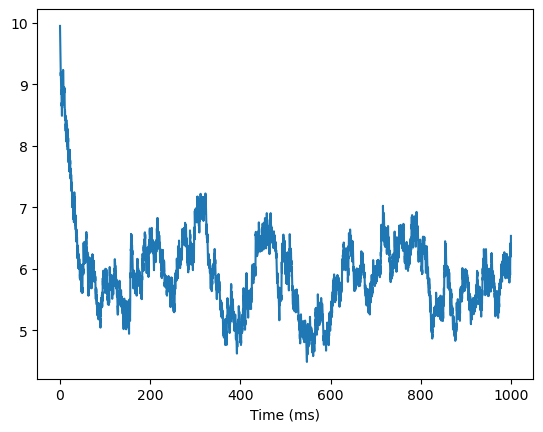

In [5]:
bp.visualize.line_plot(t, Ve, show=True)